# Tarea 6: Explotación del Knowledge Graph (Grupo Pela)


### 1. Instalación y Carga de Librerías
Dependencias necesarias:
```bash
pip install rdflib pandas folium requests matplotlib pyproj
```

In [ ]:
import pandas as pd
from rdflib import Graph, Namespace
import requests
import matplotlib.pyplot as plt

# Definición de rutas
KG_PATH = '../TAREA_4/kg/output.nt'
NS = Namespace("https://example.org/partidos/")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2. Carga del Knowledge Graph Local
Cargamos el archivo `.nt` generado en la Tarea 4.

In [2]:
g = Graph()
print(f"Cargando el grafo desde {KG_PATH}... (Esto puede tardar unos segundos)")
g.parse(KG_PATH, format='nt')
print(f"Grafo cargado. Número total de tripletas: {len(g)}")

Cargando el grafo desde ../TAREA_4/kg/output.nt... (Esto puede tardar unos segundos)
Grafo cargado. Número total de tripletas: 518641


### 3. Consultas SPARQL Locales
Realizamos una consulta para obtener el número de partidos por distrito.

In [3]:
query_distritos = """
PREFIX ns: <https://example.org/partidos/>
SELECT ?nombreDistrito (COUNT(?partido) AS ?numPartidos) ?wdURI
WHERE {
    ?partido ns:ocurreEn ?campo .
    ?campo ns:localizadoEn ?distrito .
    ?distrito ns:nombreDistrito ?nombreDistrito .
    OPTIONAL { ?distrito ns:sameAsDistrito ?wdURI . }
} 
GROUP BY ?nombreDistrito ?wdURI
ORDER BY DESC(?numPartidos)
"""

results = g.query(query_distritos)
df_distritos = pd.DataFrame(results, columns=['Distrito', 'Partidos', 'Wikidata_URI'])
df_distritos['Partidos'] = df_distritos['Partidos'].astype(int)
df_distritos.head(10)

,Distrito,Partidos,Wikidata_URI
0,Hortaleza,7335,http://www.wikidata.org/entity/Q1928529
1,Ciudad Lineal,5960,http://www.wikidata.org/entity/Q1763694
2,Tetuán,5683,http://www.wikidata.org/entity/Q1773540
3,Latina,5512,http://www.wikidata.org/entity/Q794954
4,Chamartín,4858,http://www.wikidata.org/entity/Q1766348
5,Salamanca,4530,http://www.wikidata.org/entity/Q1773521
6,,4511,http://www.wikidata.org/entity/
7,Villa de Vallecas,4501,http://www.wikidata.org/entity/Q1947988
8,Moratalaz,4486,http://www.wikidata.org/entity/Q2076109
9,Fuencarral-El Pardo,2838,http://www.wikidata.org/entity/Q656196


### 4. Enriquecimiento con Wikidata
Utilizamos las URIs obtenidas para consultar el endpoint de Wikidata y traer información adicional como la población de cada distrito.

In [10]:
def get_wikidata_stats(wd_uris):
    endpoint_url = "https://query.wikidata.org/sparql"
    
    # Filtramos URIs nulas
    uris = [f"<{u}>" for u in wd_uris if u]
    if not uris: return {}
    
    values = " ".join(uris)
    query = f"""
    SELECT ?item ?poblacion ?area ?imagen WHERE {{
      VALUES ?item {{ {values} }}
      OPTIONAL {{ ?item wdt:P1082 ?poblacion . }}
      OPTIONAL {{ ?item wdt:P2046 ?area . }}
      OPTIONAL {{ ?item wdt:P18 ?imagen . }}
    }}
    """
    
    headers = {'User-Agent': 'SportsKGExplorer/1.0', 'Accept': 'application/sparql-results+json'}
    r = requests.get(endpoint_url, params={'query': query}, headers=headers)
    data = r.json()
    
    stats = {}
    for result in data['results']['bindings']:
        uri = result['item']['value']
        stats[uri] = {
            'poblacion': result.get('poblacion', {}).get('value', 'N/A'),
            'area': result.get('area', {}).get('value', 'N/A'),
            'imagen': result.get('imagen', {}).get('value', '')
        }
    return stats

print("Consultando Wikidata...")
wd_data = get_wikidata_stats(df_distritos['Wikidata_URI'].unique())

# Añadimos la información al DataFrame
df_distritos['Poblacion'] = df_distritos['Wikidata_URI'].apply(lambda x: wd_data.get(str(x), {}).get('poblacion', 'N/A'))
df_distritos['Imagen'] = df_distritos['Wikidata_URI'].apply(lambda x: wd_data.get(str(x), {}).get('imagen', ''))
df_distritos['Area'] = df_distritos['Wikidata_URI'].apply(lambda x: wd_data.get(str(x), {}).get('area', 'N/A'))
df_distritos.head(10)

Consultando Wikidata...


,Distrito,Partidos,Wikidata_URI,Poblacion,Imagen,Area
0,Hortaleza,7335,http://www.wikidata.org/entity/Q1928529,198391,http://commons.wikimedia.org/wiki/Special:File...,27.4197624962822
1,Ciudad Lineal,5960,http://www.wikidata.org/entity/Q1763694,220345,http://commons.wikimedia.org/wiki/Special:File...,11.4256779595942
2,Tetuán,5683,http://www.wikidata.org/entity/Q1773540,160002,http://commons.wikimedia.org/wiki/Special:File...,5.37472525006254
3,Latina,5512,http://www.wikidata.org/entity/Q794954,241672,http://commons.wikimedia.org/wiki/Special:File...,25.4272030154025
4,Chamartín,4858,http://www.wikidata.org/entity/Q1766348,144796,http://commons.wikimedia.org/wiki/Special:File...,9.17548212465925
5,Salamanca,4530,http://www.wikidata.org/entity/Q1773521,145702,http://commons.wikimedia.org/wiki/Special:File...,5.3924041500993
6,,4511,http://www.wikidata.org/entity/,N/A,,N/A
7,Villa de Vallecas,4501,http://www.wikidata.org/entity/Q1947988,117501,http://commons.wikimedia.org/wiki/Special:File...,51.4672382522256
8,Moratalaz,4486,http://www.wikidata.org/entity/Q2076109,92814,http://commons.wikimedia.org/wiki/Special:File...,6.3442
9,Fuencarral-El Pardo,2838,http://www.wikidata.org/entity/Q656196,248443,http://commons.wikimedia.org/wiki/Special:File...,237.838370174431


In [6]:
from IPython.display import display, Image, HTML

df_imgs = df_distritos[df_distritos['Imagen'].astype(str).str.len() > 0].copy()

for _, row in df_imgs.iterrows():
    display(HTML(f"<h4>{row['Distrito']}</h4>"))
    display(Image(url=row['Imagen'], width=500))

### 6. Análisis: Correlación Partidos vs Población
¿Tienen los distritos más poblados más actividad deportiva registrada en nuestro KG?

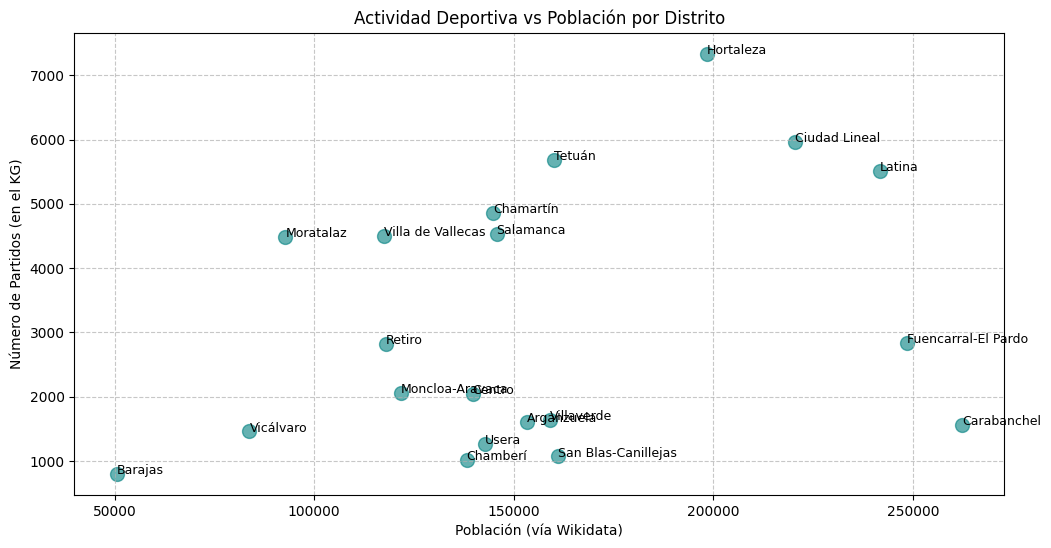

In [7]:
# Limpiamos datos para el gráfico
df_plot = df_distritos[df_distritos['Poblacion'] != 'N/A'].copy()
df_plot['Poblacion'] = df_plot['Poblacion'].astype(float)

plt.figure(figsize=(12, 6))
plt.scatter(df_plot['Poblacion'], df_plot['Partidos'], color='teal', alpha=0.6, s=100)

for i, txt in enumerate(df_plot['Distrito']):
    plt.annotate(txt, (df_plot['Poblacion'].iloc[i], df_plot['Partidos'].iloc[i]), fontsize=9)

plt.title("Actividad Deportiva vs Población por Distrito")
plt.xlabel("Población (vía Wikidata)")
plt.ylabel("Número de Partidos (en el KG)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

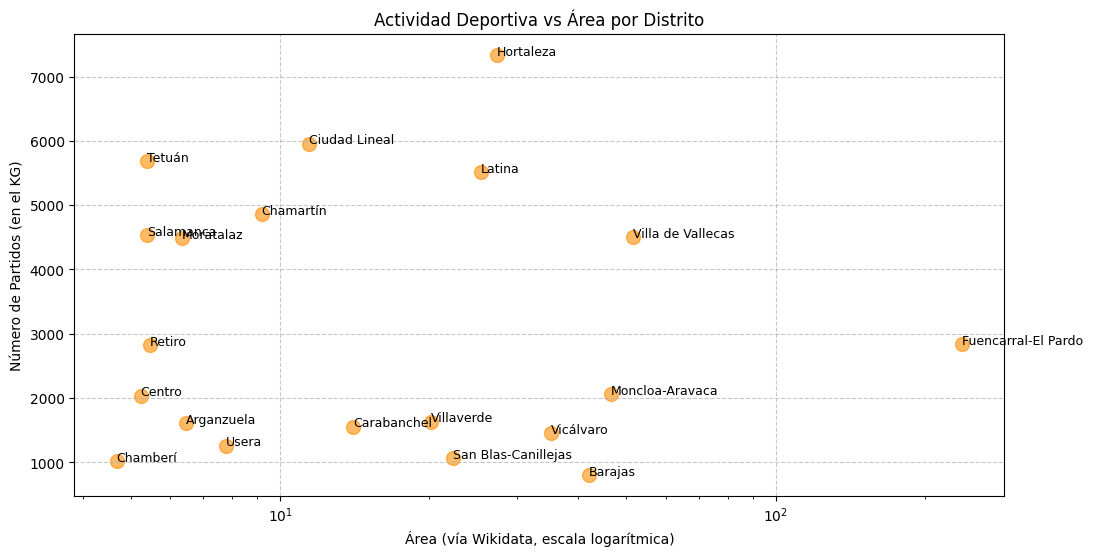

In [9]:
# Añadimos el área al dataframe y filtramos valores válidos
df_distritos['Area'] = df_distritos['Wikidata_URI'].apply(
    lambda x: wd_data.get(str(x), {}).get('area', 'N/A')
)

df_area = df_distritos[df_distritos['Area'] != 'N/A'].copy()
df_area['Area'] = df_area['Area'].astype(float)

plt.figure(figsize=(12, 6))
plt.scatter(df_area['Area'], df_area['Partidos'], color='darkorange', alpha=0.6, s=100)

for i, txt in enumerate(df_area['Distrito']):
    plt.annotate(txt, (df_area['Area'].iloc[i], df_area['Partidos'].iloc[i]), fontsize=9)

plt.xscale('log')
plt.title("Actividad Deportiva vs Área por Distrito")
plt.xlabel("Área (vía Wikidata, escala logarítmica)")
plt.ylabel("Número de Partidos (en el KG)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()